In [1]:
import sys
import squidpy as sq
import scanpy as sc
import anndata as ad
import pandas as pd
import numpy as np
import os
import gc
import re

In [2]:
import seaborn as sns
from matplotlib import pyplot as plt
import matplotlib as mpl
from matplotlib.ticker import MaxNLocator

from matplotlib.collections import PathCollection
np.random.seed(42)

In [3]:
# Load preprocessed RNA matrix of a brain section
adata_filtered = ad.read_h5ad('input/RNA_processed_2nd_brain.h5ad')

In [4]:
# 1. Backup original coordinates
original_coords = adata_filtered.obsm["spatial"].copy()

# 2. orient spatial coordinate
theta = np.radians(-135)
rotation_matrix = np.array([
    [np.cos(theta), -np.sin(theta)],
    [np.sin(theta),  np.cos(theta)]
])
rotated_coords = original_coords @ rotation_matrix.T
adata_filtered.obsm["spatial_rotated"] = rotated_coords  # store in new obsm

In [5]:
def plot_genes_in_batches(            # output each gene's plot as a pdf file
    adata,
    genes,
    batch_size=3,
    outdir="gene_pattern_plots",
    dpi=300,
    rasterize=True,
    fmt="pdf",
):
    """
    Plot spatial scatter for each gene and save each gene as an individual file.
    Keeps Squidpy's size and cmap, ensures filled dots with correct colors.
    """
    os.makedirs(outdir, exist_ok=True)
    n_batches = (len(genes) + batch_size - 1) // batch_size

    for batch_idx in range(n_batches):
        batch_genes = genes[batch_idx * batch_size : (batch_idx + 1) * batch_size]

        for gene in batch_genes:
            fig, ax = plt.subplots(figsize=(5, 5))

            sq.pl.spatial_scatter(
                adata,
                color=gene,
                spatial_key="spatial_rotated",
                shape=None,
                size=1,
                cmap="Blues",
                ax=ax,
                colorbar=False,
                library_id="one",
                # show=False,
            )

            clean_gene = str(gene).strip("'")
            ax.set_title(clean_gene)
            ax.axis("off")

            sc_collection = None
            for coll in ax.collections:
                if isinstance(coll, PathCollection):
                    sc_collection = coll

                    # Explicitly set facecolors to mapped array to keep bright color
                    array = coll.get_array()
                    cmap = getattr(coll, "cmap", plt.cm.Blues)
                    norm = getattr(coll, "norm", None)
                    if array is not None:
                        if norm is not None:
                            coll.set_facecolors(cmap(norm(array)))
                        else:
                            coll.set_facecolors(cmap(array))
                    
                    coll.set_edgecolors("none")  # remove black outlines
                    coll.set_linewidths(0)
                    coll.set_alpha(1.0)
                    if rasterize:
                        coll.set_rasterized(True)
                    break

            if sc_collection is not None:
                cbar = fig.colorbar(sc_collection, ax=ax, fraction=0.026, pad=0.04)
                cbar.locator = MaxNLocator(integer=True)
                cbar.update_ticks()

            plt.tight_layout()

            safe_name = re.sub(r"[^\w\-_\. ]", "_", clean_gene)
            outpath = os.path.join(outdir, f"{safe_name}.{fmt}")
            plt.savefig(outpath, dpi=dpi, bbox_inches="tight")
            plt.close(fig)

In [11]:
plot_genes_in_batches(adata_filtered, list(adata_filtered.var_names[2:5]), batch_size=3)

In [12]:
def plot_genes_show(adata, genes, batch_size=3):    # show plots by batches
    """
    Plot spatial scatter plots of genes in batches, without forcing color scale limits.

    Parameters:
    - adata: AnnData object with spatial data
    - genes: list of gene names to plot
    - batch_size: number of genes per figure
    """
    n_batches = (len(genes) + batch_size - 1) // batch_size

    for batch_idx in range(n_batches):
        batch_genes = genes[batch_idx * batch_size : (batch_idx + 1) * batch_size]

        ncols = batch_size
        nrows = 1

        fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 5 * nrows))
        if ncols == 1:
            axes = [axes]

        for i, gene in enumerate(batch_genes):
            ax = axes[i]
            sq.pl.spatial_scatter(
                adata,
                color=gene,
                spatial_key="spatial_rotated",
                shape=None,
                size=0.02,
                cmap="Blues",
                ax=ax,
                # show=False,
                colorbar=False,
                library_id="one",
            )
            clean_gene = gene.strip("'")
            ax.set_title(clean_gene)
            # ax.set_title(gene)
            ax.axis("off")

            # Manually create smaller colorbar for this axis
            # Get the scatter collection plotted by squidpy (last collection in ax)
            sc_collection = None
            for coll in reversed(ax.collections):
                # Usually the last PathCollection is the scatter
                if isinstance(coll, PathCollection):
                    sc_collection = coll
                    break

            if sc_collection:
                cbar = fig.colorbar(sc_collection, ax=ax, fraction=0.026, pad=0.04)  # smaller size
                cbar.locator = MaxNLocator(integer=True)
                cbar.update_ticks()

        plt.tight_layout()
        plt.show()

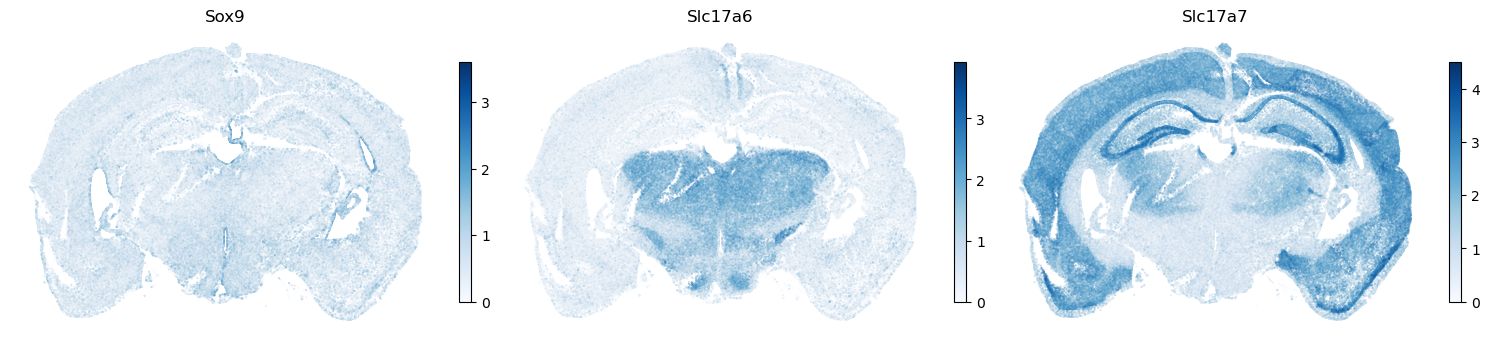

In [15]:
plot_genes_show(adata_filtered, list(adata_filtered.var_names[2:5]), batch_size=3) 
# change numbers in var_names[2:5], e.g., var_names[0:10] to show other genes